AdaGrad and Adam


1. Import libraries and create output folders


In [1]:
# Libraries used by the experiment
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# Files generated by later experiment and figure cells
OUTPUT_DIR = Path("results")
FIGURE_DIR = Path("figures")

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)


2. Define the objective functions


In [2]:
def quadratic(x):
    return float(x[0] ** 2 + x[1] ** 2)


def quadratic_gradient(x):
    return np.array(
        [2.0 * x[0], 2.0 * x[1]],
        dtype=float,
    )


def rosenbrock(x):
    return float(
        (1.0 - x[0]) ** 2
        + 100.0 * (x[1] - x[0] ** 2) ** 2
    )


def rosenbrock_gradient(x):
    return np.array(
        [
            -2.0 * (1.0 - x[0])
            - 400.0 * x[0] * (x[1] - x[0] ** 2),
            200.0 * (x[1] - x[0] ** 2),
        ],
        dtype=float,
    )


def cosine_bumps(x):
    return float(
        x[0] ** 2
        + x[1] ** 2
        + 10.0 * np.cos(x[0])
        + 10.0 * np.cos(x[1])
    )


def cosine_bumps_gradient(x):
    return np.array(
        [
            2.0 * x[0] - 10.0 * np.sin(x[0]),
            2.0 * x[1] - 10.0 * np.sin(x[1]),
        ],
        dtype=float,
    )


FUNCTIONS = {
    "quadratic": {
        "label": r"$f_1(x,y)=x^2+y^2$",
        "fun": quadratic,
        "grad": quadratic_gradient,
    },
    "rosenbrock": {
        "label": r"$f_2(x,y)=(1-x)^2+100(y-x^2)^2$",
        "fun": rosenbrock,
        "grad": rosenbrock_gradient,
    },
    "cosine_bumps": {
        "label": r"$f_3(x,y)=x^2+y^2+10\cos x+10\cos y$",
        "fun": cosine_bumps,
        "grad": cosine_bumps_gradient,
    },
}


3.  Record the experiment settings


In [3]:
STARTS = {
    "start_1": (-2.0, 2.0),
    "start_2": (0.5, -1.5),
    "start_3": (3.0, 3.0),
}

LEARNING_RATES = (0.001, 0.01, 0.1)
TOLERANCE = 1e-6
MAX_ITERATIONS = 2000
REPEATS = 10
EPSILON = 1e-8


4. Define the shared result record


In [4]:
def _result(
    x,
    objective,
    gradient,
    trajectory,
    objective_history,
    iterations,
    elapsed,
    reason,
):
    return {
        "final_x": np.asarray(x, dtype=float).copy(),
        "final_value": float(objective(x)),
        "iterations": int(iterations),
        "runtime_seconds": float(elapsed),
        "termination_reason": reason,
        "final_gradient_norm": (
            float(np.linalg.norm(gradient(x)))
            if np.all(np.isfinite(x))
            else np.nan
        ),
        "final_update_norm": (
            float(np.linalg.norm(trajectory[-1] - trajectory[-2]))
            if len(trajectory) > 1
            else 0.0
        ),
        "trajectory": np.asarray(trajectory, dtype=float),
        "objective_history": np.asarray(objective_history, dtype=float),
    }


5. View the three objective landscapes


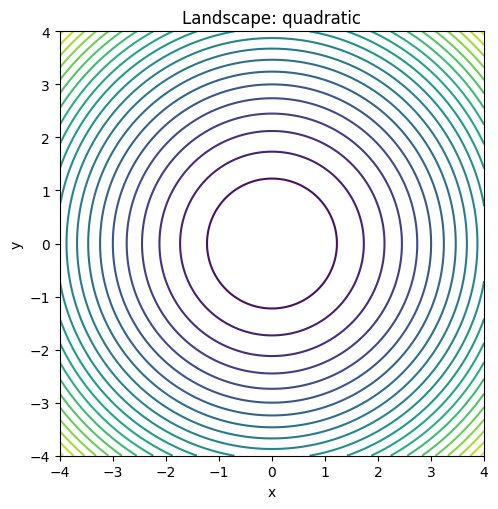

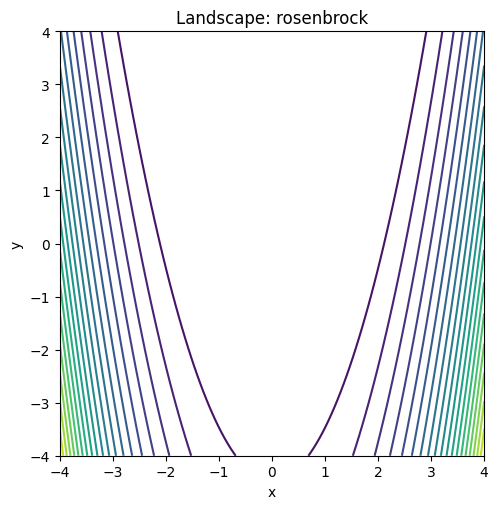

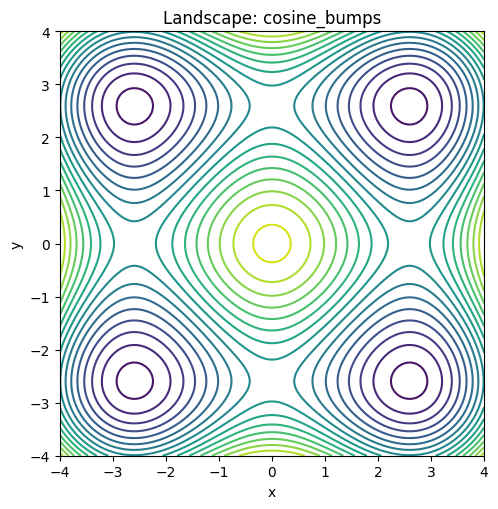

In [5]:
grid = np.linspace(-4.0, 4.0, 140)
X, Y = np.meshgrid(grid, grid)

for function_name, specification in FUNCTIONS.items():
    figure, axis = plt.subplots(figsize=(6.8, 5.2))
    Z = np.array(
        [
            [
                specification["fun"](np.array([x, y]))
                for x in grid
            ]
            for y in grid
        ]
    )

    axis.contour(X, Y, Z, levels=22, cmap="viridis")
    axis.set_title(f"Landscape: {function_name}")
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_aspect("equal", adjustable="box")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


Optimizer implementations

Each optimizer is defined in its own code cell. This makes the state variables and stopping rule easier to inspect without changing the update logic.


6. Adagrad Implementation

In [6]:
def adagrad(
    objective,
    gradient,
    start,
    learning_rate,
    tolerance=TOLERANCE,
    max_iterations=MAX_ITERATIONS,
    epsilon=EPSILON,
):
    """AdaGrad with fresh accumulated-gradient state per call."""
    x = np.asarray(start, dtype=float).copy()
    accumulated = np.zeros_like(x)
    trajectory = [x.copy()]
    objective_history = [objective(x)]

    start_time = time.perf_counter()
    reason = "iteration_limit"
    iterations = 0

    if not (
        np.all(np.isfinite(x))
        and np.isfinite(objective_history[0])
    ):
        return _result(
            x,
            objective,
            gradient,
            trajectory,
            objective_history,
            0,
            0.0,
            "non_finite_failure",
        )

    for iteration in range(1, max_iterations + 1):
        grad = gradient(x)

        if not (
            np.all(np.isfinite(x))
            and np.all(np.isfinite(grad))
        ):
            reason, iterations = "non_finite_failure", iteration - 1
            break

        accumulated += grad ** 2
        if not np.all(np.isfinite(accumulated)):
            reason = "non_finite_failure"
            break

        step = learning_rate * grad / (
            np.sqrt(accumulated) + epsilon
        )
        if not np.all(np.isfinite(step)):
            reason = "non_finite_failure"
            break

        new_x = x - step
        iterations = iteration
        trajectory.append(new_x.copy())
        objective_history.append(objective(new_x))

        if not (
            np.all(np.isfinite(new_x))
            and np.isfinite(objective_history[-1])
        ):
            x = new_x
            reason = "non_finite_failure"
            break

        x = new_x
        if np.linalg.norm(step) < tolerance:
            reason = "step_tolerance"
            break

    elapsed = time.perf_counter() - start_time
    return _result(
        x,
        objective,
        gradient,
        trajectory,
        objective_history,
        iterations,
        elapsed,
        reason,
    )


7. Adam Implementation

In [7]:
def adam(
    objective,
    gradient,
    start,
    learning_rate,
    tolerance=TOLERANCE,
    max_iterations=MAX_ITERATIONS,
    beta1=0.9,
    beta2=0.999,
    epsilon=EPSILON,
):
    """Adam with bias correction and fresh moment state per call."""
    x = np.asarray(start, dtype=float).copy()
    first_moment = np.zeros_like(x)
    second_moment = np.zeros_like(x)
    trajectory = [x.copy()]
    objective_history = [objective(x)]

    start_time = time.perf_counter()
    reason = "iteration_limit"
    iterations = 0

    if not (
        np.all(np.isfinite(x))
        and np.isfinite(objective_history[0])
    ):
        return _result(
            x,
            objective,
            gradient,
            trajectory,
            objective_history,
            0,
            0.0,
            "non_finite_failure",
        )

    for iteration in range(1, max_iterations + 1):
        grad = gradient(x)

        if not (
            np.all(np.isfinite(x))
            and np.all(np.isfinite(grad))
        ):
            reason, iterations = "non_finite_failure", iteration - 1
            break

        first_moment = (
            beta1 * first_moment
            + (1.0 - beta1) * grad
        )
        second_moment = (
            beta2 * second_moment
            + (1.0 - beta2) * (grad ** 2)
        )

        if not (
            np.all(np.isfinite(first_moment))
            and np.all(np.isfinite(second_moment))
        ):
            reason = "non_finite_failure"
            break

        first_corrected = first_moment / (
            1.0 - beta1 ** iteration
        )
        second_corrected = second_moment / (
            1.0 - beta2 ** iteration
        )
        step = learning_rate * first_corrected / (
            np.sqrt(second_corrected) + epsilon
        )

        if not np.all(np.isfinite(step)):
            reason = "non_finite_failure"
            break

        new_x = x - step
        iterations = iteration
        trajectory.append(new_x.copy())
        objective_history.append(objective(new_x))

        if not (
            np.all(np.isfinite(new_x))
            and np.isfinite(objective_history[-1])
        ):
            x = new_x
            reason = "non_finite_failure"
            break

        x = new_x
        if np.linalg.norm(step) < tolerance:
            reason = "step_tolerance"
            break

    elapsed = time.perf_counter() - start_time
    return _result(
        x,
        objective,
        gradient,
        trajectory,
        objective_history,
        iterations,
        elapsed,
        reason,
    )


8. Registering the optimizers.

In [8]:
OPTIMIZERS = {
    "AdaGrad": adagrad,
    "Adam": adam,
}


9. Inspecting one run before full implementation.



In [9]:
demo_function = FUNCTIONS["rosenbrock"]
demo_start = STARTS["start_1"]

for optimizer_name, optimizer in OPTIMIZERS.items():
    demo = optimizer(
        demo_function["fun"],
        demo_function["grad"],
        demo_start,
        0.001,
    )

    print(f"{optimizer_name}")
    print(f"  final point: {demo['final_x']}")
    print(f"  final value: {demo['final_value']}")
    print(f"  iterations: {demo['iterations']}")
    print(f"  status: {demo['termination_reason']}\n")


AdaGrad
  final point: [-1.9161215   2.08450877]
  final value: 260.3647332658887
  iterations: 2000
  status: iteration_limit

Adam
  final point: [-1.56270558  2.4479619 ]
  final value: 6.570956441520147
  iterations: 2000
  status: iteration_limit



 Numerical validation

The next cells check the analytic gradients, first optimizer updates, Adam bias correction, fresh optimizer state, and non-finite failure handling before the larger experiment is run.


10. Defining a finite-difference gradient reference


In [10]:
def finite_difference_gradient(objective, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    estimate = np.zeros_like(x)

    for i in range(len(x)):
        plus = x.copy()
        minus = x.copy()
        plus[i] += h
        minus[i] -= h
        estimate[i] = (
            objective(plus) - objective(minus)
        ) / (2.0 * h)

    return estimate


11. Defining the validation checks


In [11]:
def run_validation_tests():
    test_points = {
        "quadratic": np.array([0.7, -1.2]),
        "rosenbrock": np.array([-0.8, 1.4]),
        "cosine_bumps": np.array([1.1, -2.0]),
    }
    gradient_rows = []

    # Check analytic gradients against centered finite differences.
    for name, point in test_points.items():
        analytic = FUNCTIONS[name]["grad"](point)
        numerical = finite_difference_gradient(
            FUNCTIONS[name]["fun"],
            point,
        )
        error = float(np.max(np.abs(analytic - numerical)))
        gradient_rows.append(
            {"function": name, "max_abs_error": error}
        )
        assert error < 1e-6, (name, error)

    # First-step checks for a one-dimensional equivalent embedded in 2D.
    objective = lambda x: float(0.5 * np.dot(x, x))
    gradient = lambda x: np.asarray(x, dtype=float)
    start = np.array([2.0, -1.0])

    ada = adagrad(
        objective,
        gradient,
        start,
        0.1,
        max_iterations=1,
    )
    expected_ada = start - 0.1 * gradient(start) / (
        np.abs(gradient(start)) + EPSILON
    )
    assert np.allclose(ada["final_x"], expected_ada, atol=1e-8)

    ad = adam(
        objective,
        gradient,
        start,
        0.1,
        max_iterations=1,
    )
    expected_adam = start - 0.1 * gradient(start) / (
        np.abs(gradient(start)) + EPSILON
    )
    assert np.allclose(ad["final_x"], expected_adam, atol=1e-8)

    # Multi-step Adam check, including bias correction.
    manual_x = start.copy()
    m = np.zeros(2)
    v = np.zeros(2)

    for t in range(1, 4):
        g = gradient(manual_x)
        m = 0.9 * m + 0.1 * g
        v = 0.999 * v + 0.001 * g ** 2
        manual_x = manual_x - 0.1 * (
            m / (1 - 0.9 ** t)
        ) / (
            np.sqrt(v / (1 - 0.999 ** t)) + EPSILON
        )

    multi = adam(
        objective,
        gradient,
        start,
        0.1,
        max_iterations=3,
    )
    assert np.allclose(multi["final_x"], manual_x, atol=1e-8)

    # Fresh state :- identical calls must produce identical points.
    first = adam(
        objective,
        gradient,
        start,
        0.1,
        max_iterations=3,
    )
    second = adam(
        objective,
        gradient,
        start,
        0.1,
        max_iterations=3,
    )
    assert np.allclose(first["final_x"], second["final_x"])

    # Non-finite objective values should stop before the first update.
    bad = adagrad(
        lambda x: np.inf,
        gradient,
        start,
        0.1,
        max_iterations=3,
    )
    assert (
        bad["termination_reason"] == "non_finite_failure"
        and bad["iterations"] == 0
    )

    print(pd.DataFrame(gradient_rows).to_string(index=False))
    print(
        "Validation checks passed: gradients, AdaGrad/Adam first steps, "
        "Adam bias correction, and fresh state."
    )
    return pd.DataFrame(gradient_rows)


12. Run the validation checks


In [12]:
validation = run_validation_tests()


    function  max_abs_error
   quadratic   2.640532e-10
  rosenbrock   1.428083e-08
cosine_bumps   3.086091e-10
Validation checks passed: gradients, AdaGrad/Adam first steps, Adam bias correction, and fresh state.


## 4. Full experiment protocol

There are $3\times3\times2\times3=54$ configurations: three functions, three starts, two optimizers, and three learning rates. Each configuration has one untimed warm-up and ten measured repeats. The optimizer timer excludes plotting and CSV writing.

Each run records its final point and value, iteration count, runtime, termination reason, and final gradient norm. Trajectories and objective histories are saved for the first measured repeat of every configuration.


13. Define the experiment runner


In [13]:
def run_experiments():
    rows = []
    trajectory_rows = []
    history_rows = []
    config_order = 0

    for function_name, specification in FUNCTIONS.items():
        for start_name, start in STARTS.items():
            for optimizer_name, optimizer in OPTIMIZERS.items():
                for learning_rate in LEARNING_RATES:
                    config_order += 1

                    # Warm-up is separate from measured repetitions.
                    optimizer(
                        specification["fun"],
                        specification["grad"],
                        start,
                        learning_rate,
                    )

                    for repeat in range(1, REPEATS + 1):
                        outcome = optimizer(
                            specification["fun"],
                            specification["grad"],
                            start,
                            learning_rate,
                        )

                        rows.append(
                            {
                                "config_order": config_order,
                                "function": function_name,
                                "optimizer": optimizer_name,
                                "start_name": start_name,
                                "start_x": start[0],
                                "start_y": start[1],
                                "learning_rate": learning_rate,
                                "repeat": repeat,
                                "final_x": outcome["final_x"][0],
                                "final_y": outcome["final_x"][1],
                                "final_value": outcome["final_value"],
                                "iterations": outcome["iterations"],
                                "runtime_seconds": outcome[
                                    "runtime_seconds"
                                ],
                                "termination_reason": outcome[
                                    "termination_reason"
                                ],
                                "final_gradient_norm": outcome[
                                    "final_gradient_norm"
                                ],
                                "final_update_norm": outcome[
                                    "final_update_norm"
                                ],
                                "epsilon": EPSILON,
                                "beta1": (
                                    0.9
                                    if optimizer_name == "Adam"
                                    else np.nan
                                ),
                                "beta2": (
                                    0.999
                                    if optimizer_name == "Adam"
                                    else np.nan
                                ),
                                "tolerance": TOLERANCE,
                                "max_iterations": MAX_ITERATIONS,
                            }
                        )

                        if repeat == 1:
                            for step, point in enumerate(
                                outcome["trajectory"]
                            ):
                                trajectory_rows.append(
                                    {
                                        "config_order": config_order,
                                        "function": function_name,
                                        "optimizer": optimizer_name,
                                        "start_name": start_name,
                                        "learning_rate": learning_rate,
                                        "step": step,
                                        "x": point[0],
                                        "y": point[1],
                                        "objective_value": outcome[
                                            "objective_history"
                                        ][step],
                                    }
                                )

                            for step, value in enumerate(
                                outcome["objective_history"]
                            ):
                                history_rows.append(
                                    {
                                        "config_order": config_order,
                                        "function": function_name,
                                        "optimizer": optimizer_name,
                                        "start_name": start_name,
                                        "learning_rate": learning_rate,
                                        "step": step,
                                        "objective_value": value,
                                    }
                                )

    raw = pd.DataFrame(rows)
    trajectories = pd.DataFrame(trajectory_rows)
    histories = pd.DataFrame(history_rows)

    grouped = raw.groupby(
        [
            "config_order",
            "function",
            "optimizer",
            "start_name",
            "start_x",
            "start_y",
            "learning_rate",
            "epsilon",
            "beta1",
            "beta2",
            "tolerance",
            "max_iterations",
        ],
        sort=True,
        dropna=False,
    )
    summary = grouped.agg(
        runs=("repeat", "count"),
        final_value_mean=("final_value", "mean"),
        final_value_std=("final_value", "std"),
        final_x_mean=("final_x", "mean"),
        final_x_std=("final_x", "std"),
        final_y_mean=("final_y", "mean"),
        final_y_std=("final_y", "std"),
        iterations_mean=("iterations", "mean"),
        iterations_std=("iterations", "std"),
        runtime_seconds_mean=("runtime_seconds", "mean"),
        runtime_seconds_std=("runtime_seconds", "std"),
        final_gradient_norm_mean=("final_gradient_norm", "mean"),
        final_gradient_norm_std=("final_gradient_norm", "std"),
        final_update_norm_mean=("final_update_norm", "mean"),
        final_update_norm_std=("final_update_norm", "std"),
    ).reset_index()
    summary["termination_reasons"] = (
        grouped["termination_reason"]
        .agg(lambda values: ", ".join(sorted(set(values))))
        .to_numpy()
    )

    raw.to_csv(OUTPUT_DIR / "adagrad_adam_raw_results.csv", index=False)
    summary.to_csv(OUTPUT_DIR / "adagrad_adam_summary.csv", index=False)
    trajectories.to_csv(
        OUTPUT_DIR / "adagrad_adam_trajectories.csv",
        index=False,
    )
    histories.to_csv(
        OUTPUT_DIR / "adagrad_adam_objective_histories.csv",
        index=False,
    )

    return raw, summary, trajectories, histories


14. Run the experiment and inspect its summary


In [14]:
raw_results, summary_results, trajectory_results, history_results = (
    run_experiments()
)

print(f"raw rows: {len(raw_results)}")
print(f"summary rows: {len(summary_results)}")
display(summary_results.head())


raw rows: 540
summary rows: 54


,config_order,function,optimizer,start_name,start_x,start_y,learning_rate,epsilon,beta1,beta2,...,final_y_std,iterations_mean,iterations_std,runtime_seconds_mean,runtime_seconds_std,final_gradient_norm_mean,final_gradient_norm_std,final_update_norm_mean,final_update_norm_std,termination_reasons
0,1,quadratic,AdaGrad,start_1,-2.0,2.0,0.001,1.000000e-08,NaN,NaN,...,0.0,2000.0,0.0,0.066652,0.006955,5.409877,0.0,3.114123e-05,0.0,iteration_limit
1,2,quadratic,AdaGrad,start_1,-2.0,2.0,0.010,1.000000e-08,NaN,NaN,...,0.0,2000.0,0.0,0.060565,0.003984,3.384760,0.0,2.578849e-04,0.0,iteration_limit
2,3,quadratic,AdaGrad,start_1,-2.0,2.0,0.100,1.000000e-08,NaN,NaN,...,0.0,1098.0,0.0,0.032578,0.002304,0.000224,0.0,9.926384e-07,0.0,step_tolerance
3,4,quadratic,Adam,start_1,-2.0,2.0,0.001,1.000000e-08,0.9,0.999,...,0.0,2000.0,0.0,0.080001,0.003918,1.390051,0.0,6.985652e-04,0.0,iteration_limit
4,5,quadratic,Adam,start_1,-2.0,2.0,0.010,1.000000e-08,0.9,0.999,...,0.0,796.0,0.0,0.032211,0.003666,0.000079,0.0,9.775475e-07,0.0,step_tolerance


## 5.Figures and representative runs

The figure cell saves one landscape per function, one two-panel trajectory figure per function, one learning-rate comparison, and one objective-history comparison. Figure sizes and spacing are set for readability.


### 15. Create the saved figures


In [15]:
def make_figures(raw, summary, trajectories, histories):
    # Landscapes with the three prescribed starting points.
    grid = np.linspace(-4.0, 4.0, 180)
    X, Y = np.meshgrid(grid, grid)

    for function_name, specification in FUNCTIONS.items():
        Z = np.array(
            [
                [
                    specification["fun"](np.array([x, y]))
                    for x in grid
                ]
                for y in grid
            ]
        )
        figure, axis = plt.subplots(figsize=(7.0, 5.6))
        levels = np.linspace(
            np.nanmin(Z),
            np.nanpercentile(Z, 92),
            24,
        )
        axis.contour(X, Y, Z, levels=levels, cmap="viridis")

        for start_name, start in STARTS.items():
            axis.scatter(
                *start,
                marker="o",
                s=45,
                label=f"{start_name.replace('start_', 'start ')}",
            )

        axis.set_title(f"Landscape: {function_name}")
        axis.set_xlabel("x")
        axis.set_ylabel("y")
        axis.set_aspect("equal", adjustable="box")
        axis.legend(fontsize=8, loc="upper left")
        figure.tight_layout()
        figure.savefig(
            FIGURE_DIR / f"landscape_{function_name}.png",
            dpi=180,
        )
        plt.close(figure)

    # One representative trajectory per function and optimizer.
    finite = raw[np.isfinite(raw["final_value"])].copy()
    best = (
        finite.sort_values(
            [
                "function",
                "optimizer",
                "final_value",
                "iterations",
                "config_order",
                "repeat",
            ]
        )
        .drop_duplicates(
            ["function", "optimizer"],
            keep="first",
        )
    )
    best.to_csv(OUTPUT_DIR / "representative_runs.csv", index=False)

    for function_name in FUNCTIONS:
        figure, axes = plt.subplots(
            1,
            2,
            figsize=(13.5, 5.2),
            constrained_layout=True,
        )

        for axis, optimizer_name in zip(axes, OPTIMIZERS):
            selected = best[
                (best["function"] == function_name)
                & (best["optimizer"] == optimizer_name)
            ].iloc[0]
            path = trajectories[
                (trajectories["config_order"] == selected["config_order"])
                & (trajectories["optimizer"] == optimizer_name)
            ]

            # Draw contours behind the path.
            x_low = path["x"].min() - 0.5
            x_high = path["x"].max() + 0.5
            y_low = path["y"].min() - 0.5
            y_high = path["y"].max() + 0.5
            grid_x = np.linspace(x_low, x_high, 150)
            grid_y = np.linspace(y_low, y_high, 150)
            contour_X, contour_Y = np.meshgrid(grid_x, grid_y)
            specification = FUNCTIONS[function_name]
            Z = np.array(
                [
                    [
                        specification["fun"](np.array([xx, yy]))
                        for xx in grid_x
                    ]
                    for yy in grid_y
                ]
            )
            finite_z = Z[np.isfinite(Z)]

            if function_name == "rosenbrock":
                levels = np.geomspace(
                    max(1e-3, finite_z.min()),
                    max(1e-3, finite_z.max()),
                    18,
                )
            else:
                levels = 18

            axis.contour(
                contour_X,
                contour_Y,
                Z,
                levels=levels,
                colors="#aaaaaa",
                linewidths=0.65,
                zorder=0,
            )
            axis.plot(
                path["x"],
                path["y"],
                linewidth=1.2,
                color="tab:blue",
            )
            axis.scatter(
                path.iloc[0]["x"],
                path.iloc[0]["y"],
                c="tab:green",
                marker="o",
                label=(
                    f"start: "
                    f"{selected['start_name'].replace('start_', '')}"
                ),
                zorder=4,
            )
            axis.scatter(
                path.iloc[-1]["x"],
                path.iloc[-1]["y"],
                c="tab:red",
                marker="X",
                label="final",
                zorder=5,
            )
            axis.set_title(
                f"{optimizer_name} | "
                f"learning rate = {selected['learning_rate']}\n"
                f"status: {selected['termination_reason']}"
            )
            axis.set_xlabel("x")
            axis.set_ylabel("y")
            axis.legend(fontsize=8)
            axis.set_xlim(x_low, x_high)
            axis.set_ylim(y_low, y_high)

        figure.suptitle(
            f"Representative trajectories: {function_name}",
            fontsize=15,
        )
        figure.savefig(
            FIGURE_DIR / f"trajectories_{function_name}.png",
            dpi=180,
        )
        plt.close(figure)

    # Learning-rate comparison of final values.
    grouped = (
        summary.groupby(
            ["function", "optimizer", "learning_rate"],
            sort=True,
        )["final_value_mean"]
        .mean()
        .reset_index()
    )
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(15.0, 4.8),
        constrained_layout=True,
    )

    for axis, function_name in zip(axes, FUNCTIONS):
        data = grouped[grouped["function"] == function_name]

        for optimizer_name in OPTIMIZERS:
            part = data[data["optimizer"] == optimizer_name]
            axis.plot(
                part["learning_rate"],
                part["final_value_mean"],
                marker="o",
                linewidth=1.8,
                label=optimizer_name,
            )

        axis.set_xscale("log")
        axis.set_title(function_name)
        axis.set_xlabel("learning rate")
        axis.set_ylabel("mean final value")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)

    figure.suptitle("Learning-rate comparison", fontsize=15)
    figure.savefig(
        FIGURE_DIR / "learning_rate_comparison.png",
        dpi=180,
    )
    plt.close(figure)

    # Objective histories for representative runs.
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(15.0, 4.8),
        constrained_layout=True,
    )

    for axis, function_name in zip(axes, FUNCTIONS):
        run_notes = []

        for optimizer_name in OPTIMIZERS:
            selected = best[
                (best["function"] == function_name)
                & (best["optimizer"] == optimizer_name)
            ].iloc[0]
            path = histories[
                (histories["config_order"] == selected["config_order"])
                & (histories["optimizer"] == optimizer_name)
            ]
            axis.plot(
                path["step"],
                path["objective_value"],
                label=optimizer_name,
            )
            run_notes.append(
                f"{optimizer_name}: "
                f"start {selected['start_name'].replace('start_', '')}, "
                f"lr {selected['learning_rate']}"
            )

        if function_name != "cosine_bumps":
            axis.set_yscale("log")

        short_title = {
            "quadratic": "Quadratic",
            "rosenbrock": "Rosenbrock",
            "cosine_bumps": "Cosine bumps",
        }[function_name]
        axis.set_title(short_title)
        axis.set_xlabel("iteration")
        axis.set_ylabel("objective")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
        axis.text(
            0.02,
            0.03,
            "\n".join(run_notes),
            transform=axis.transAxes,
            fontsize=7,
            va="bottom",
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "alpha": 0.8,
            },
        )

    figure.suptitle("Representative objective histories", fontsize=15)
    figure.savefig(
        FIGURE_DIR / "objective_histories.png",
        dpi=180,
    )
    plt.close(figure)

    return best


### 16. Selecting and inspecting representative runs


In [16]:
representatives = make_figures(
    raw_results,
    summary_results,
    trajectory_results,
    history_results,
)

display(
    representatives[
        [
            "function",
            "optimizer",
            "start_name",
            "learning_rate",
            "final_value",
            "iterations",
            "termination_reason",
        ]
    ]
)


,function,optimizer,start_name,learning_rate,final_value,iterations,termination_reason
500,cosine_bumps,AdaGrad,start_3,0.1,-3.617967e+00,74,step_tolerance
470,cosine_bumps,Adam,start_2,0.1,-3.617967e+00,242,step_tolerance
80,quadratic,AdaGrad,start_2,0.1,4.164265e-09,635,step_tolerance
110,quadratic,Adam,start_2,0.1,7.963613e-11,230,step_tolerance
260,rosenbrock,AdaGrad,start_2,0.1,4.182155e-01,2000,iteration_limit
290,rosenbrock,Adam,start_2,0.1,6.876925e-06,2000,iteration_limit


### 17.Reviewing the saved figures one group at a time


#### 17a. Objective landscapes


Landscape — landscape_cosine_bumps


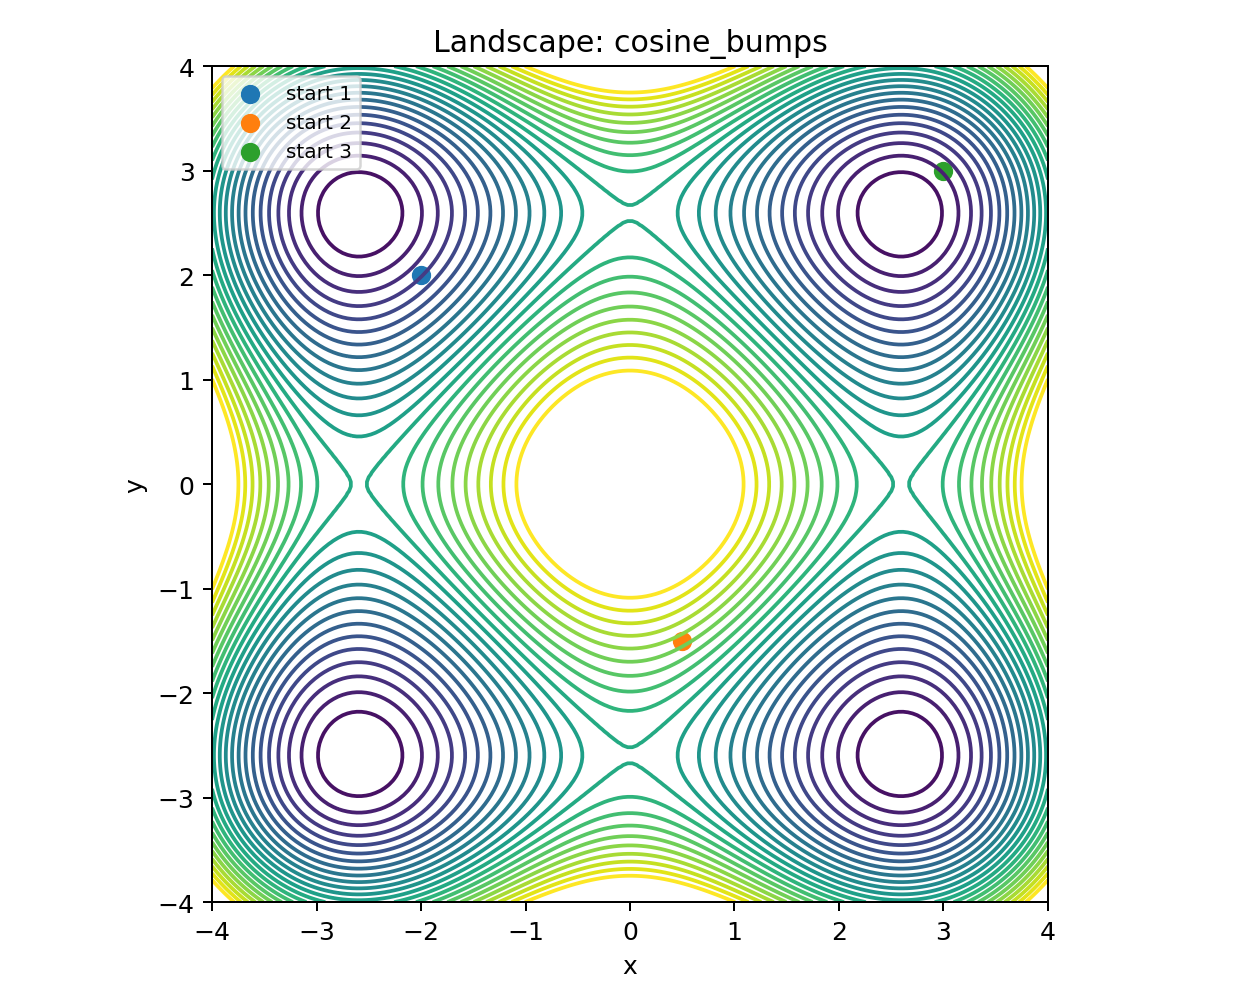


Landscape — landscape_quadratic


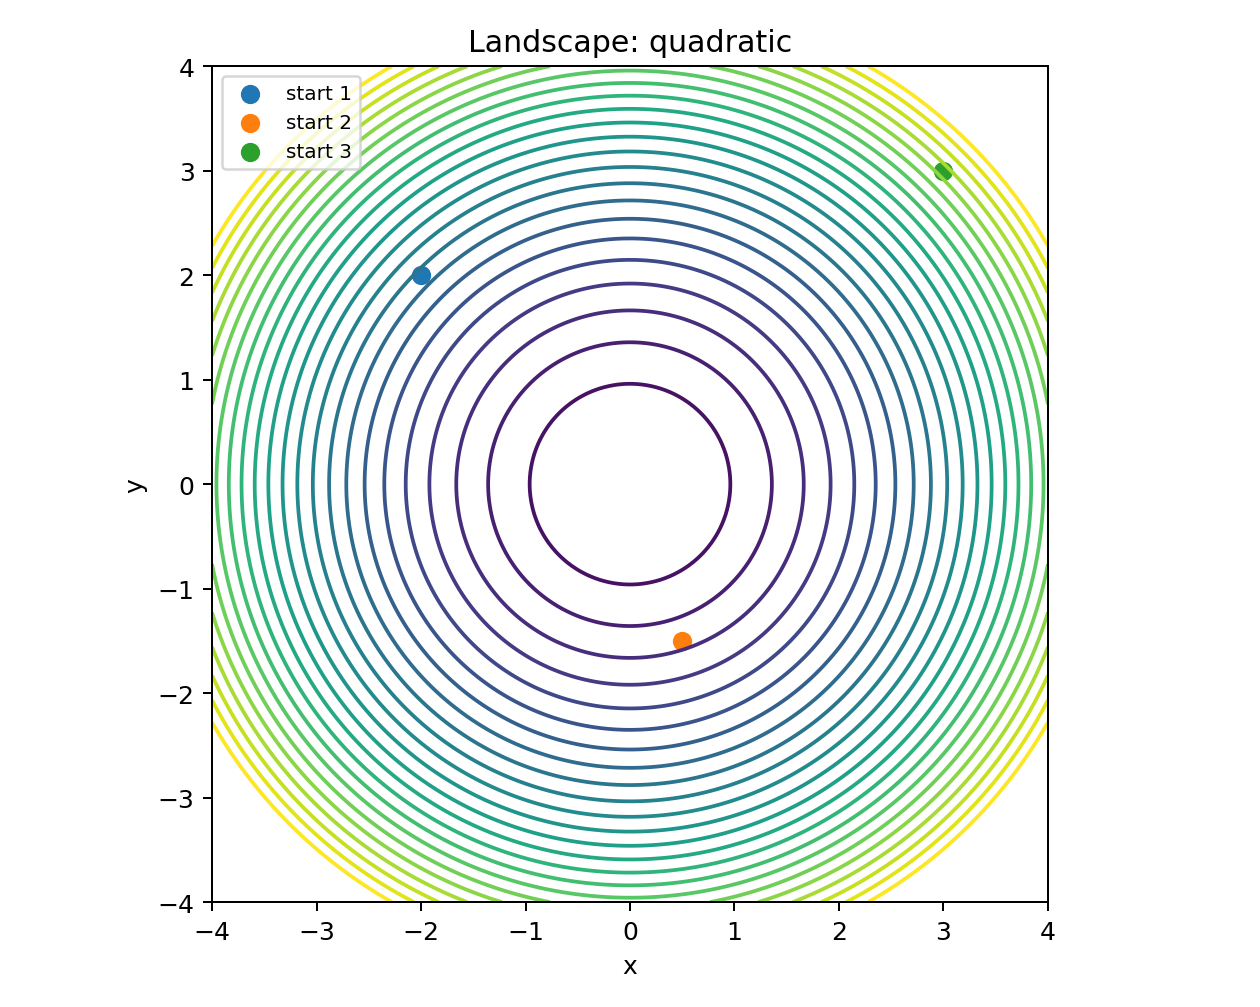


Landscape — landscape_rosenbrock


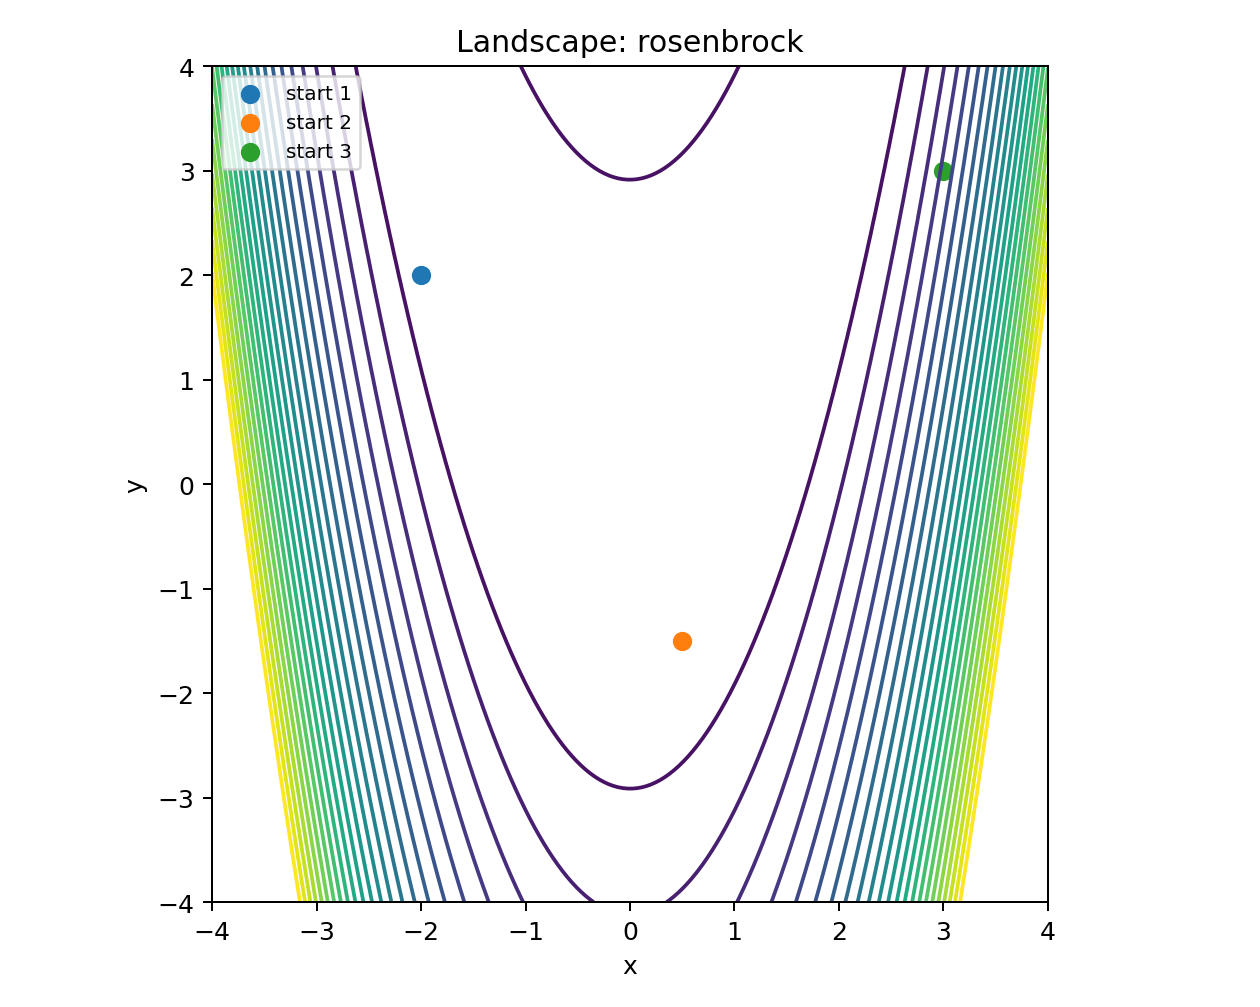

In [17]:
from IPython.display import Image, display

landscape_files = sorted(FIGURE_DIR.glob("landscape_*.png"))
for filename in landscape_files:
    print(f"Landscape — {filename.stem}")
    display(Image(filename=str(filename)))
    print()


#### 17b. Representative trajectories


Trajectories — trajectories_cosine_bumps


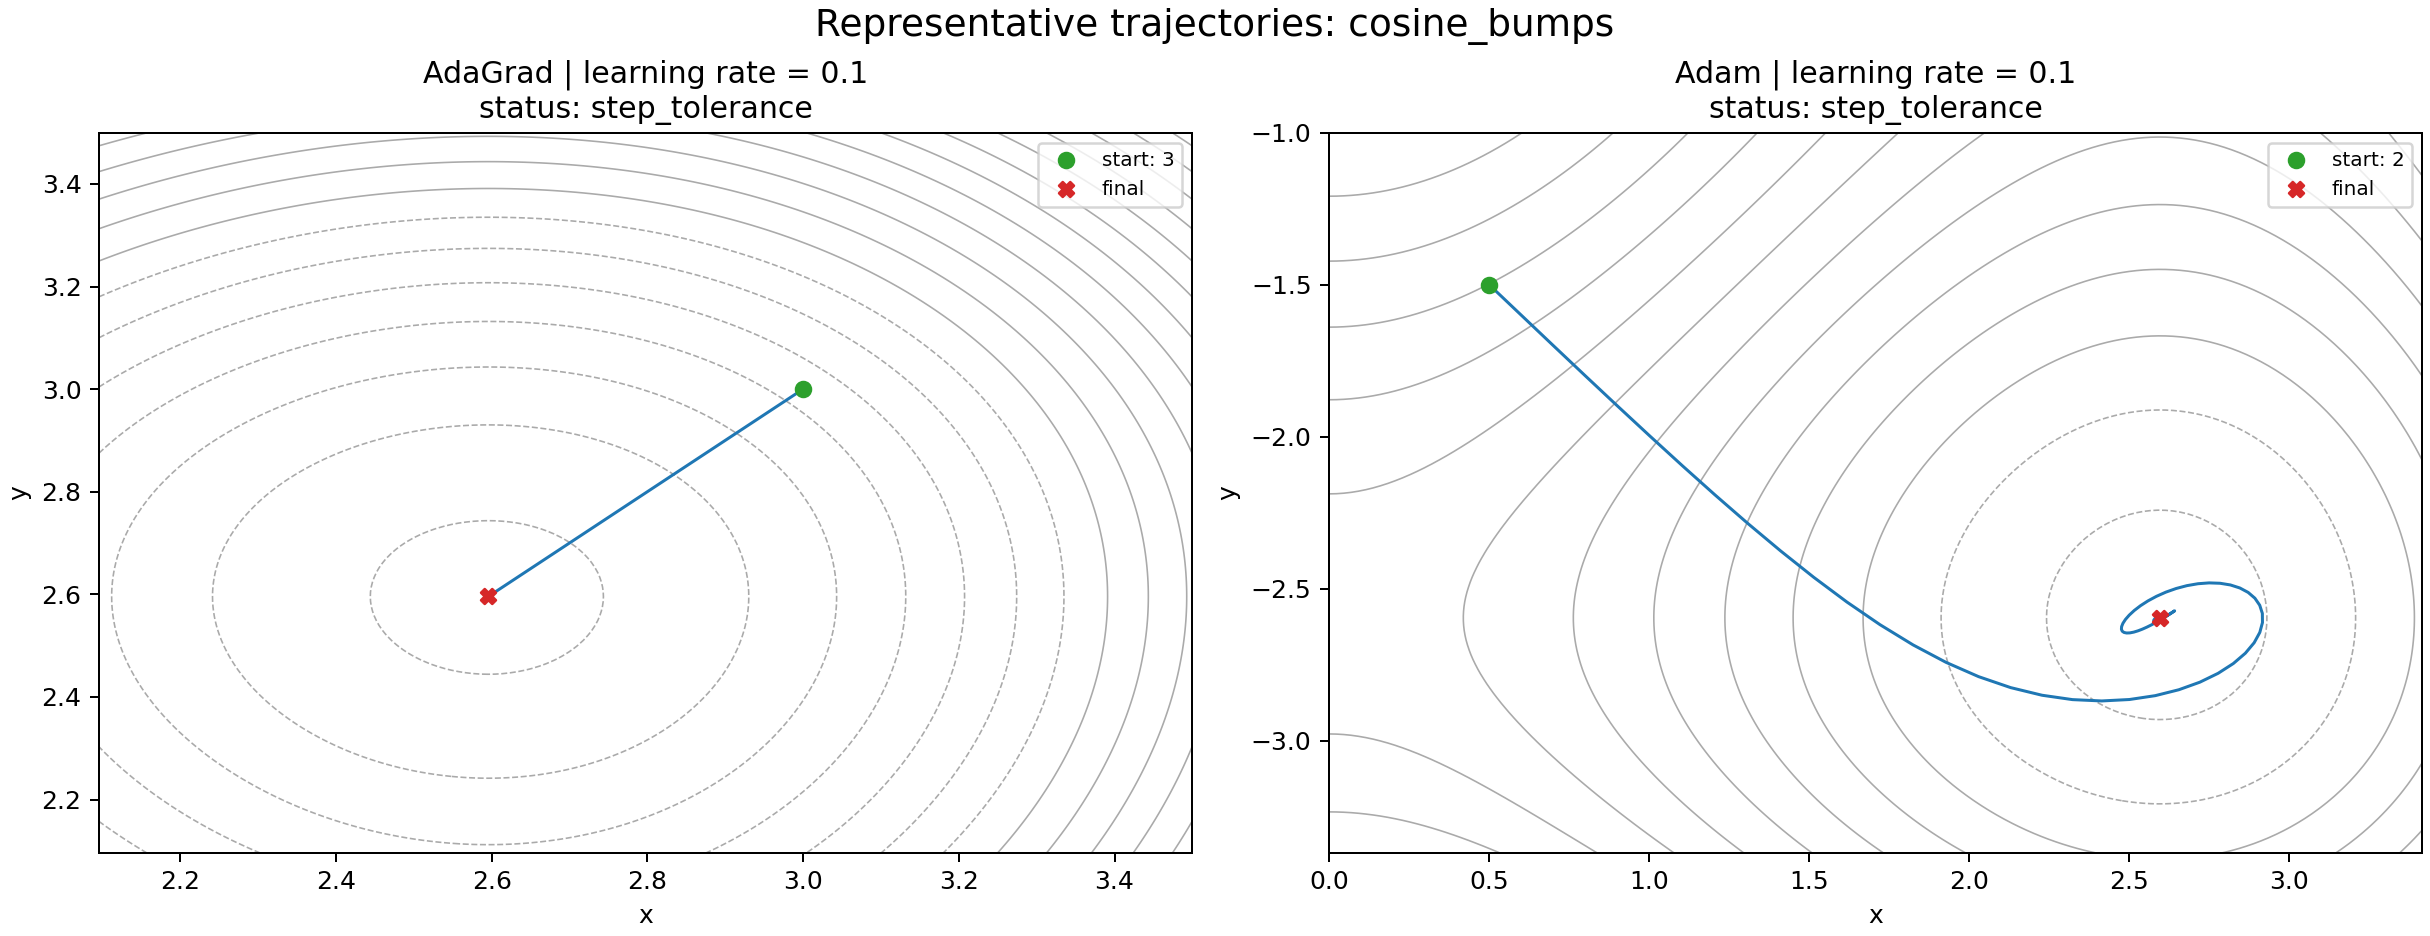


Trajectories — trajectories_quadratic


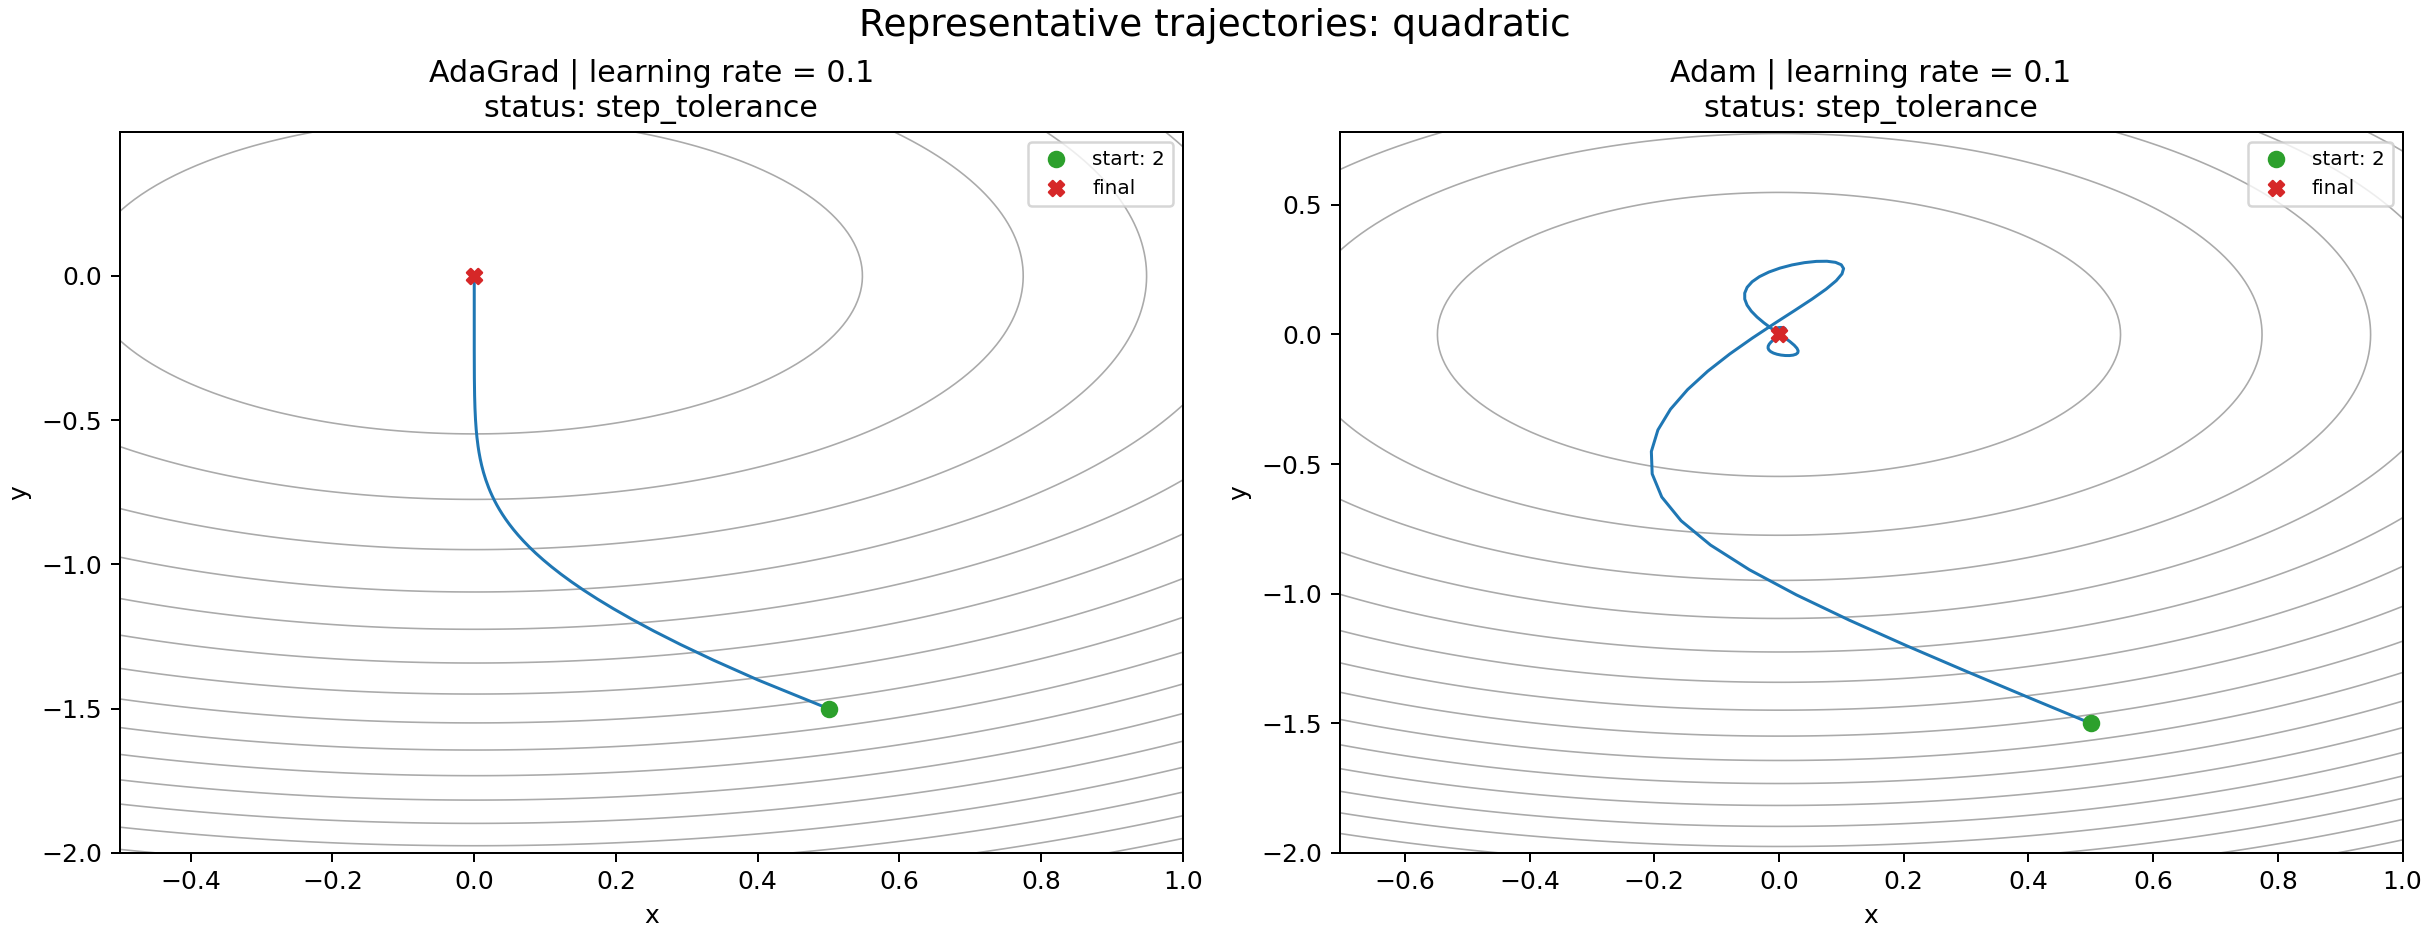


Trajectories — trajectories_rosenbrock


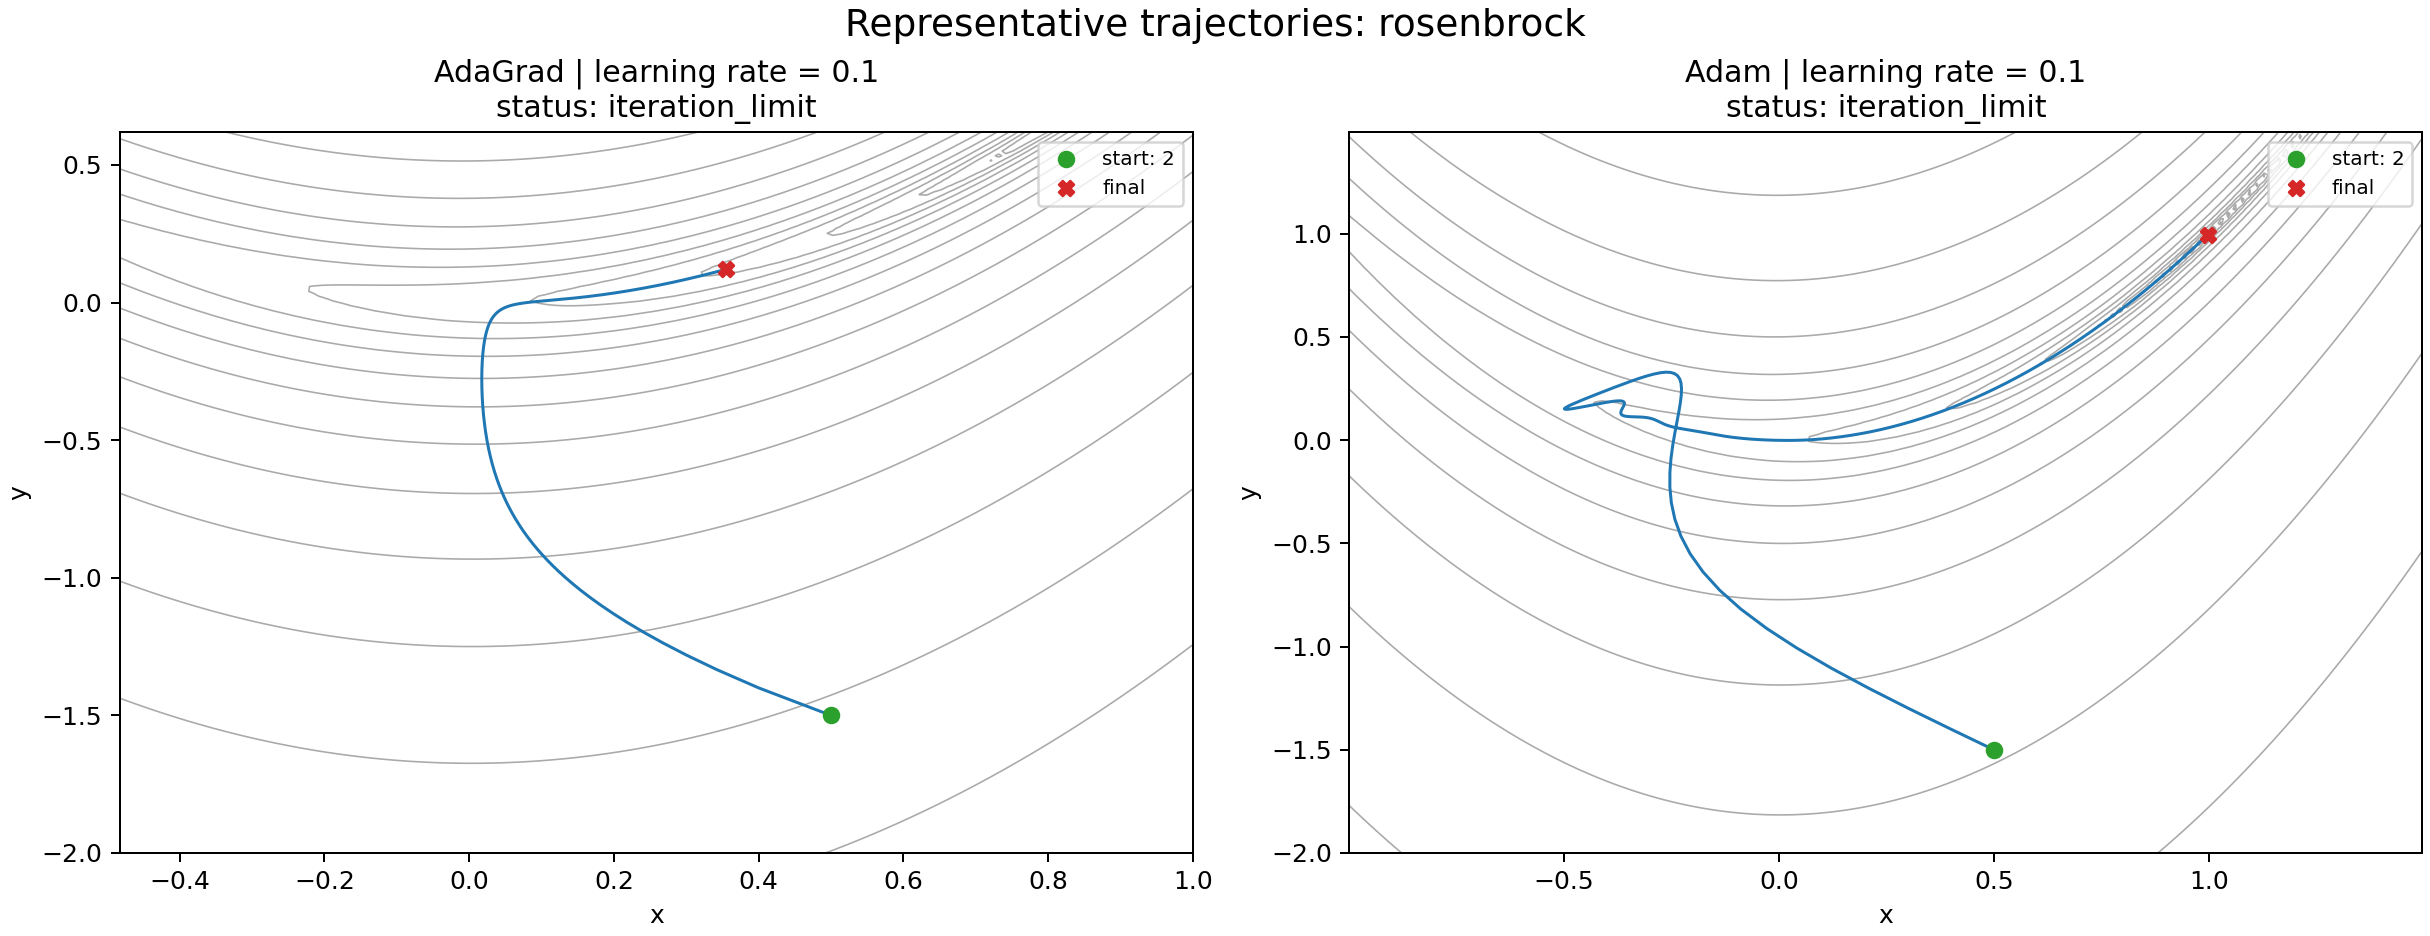

In [18]:
trajectory_files = sorted(FIGURE_DIR.glob("trajectories_*.png"))
for filename in trajectory_files:
    print(f"Trajectories — {filename.stem}")
    display(Image(filename=str(filename)))
    print()


#### 17c. Learning-rate comparison


Learning-rate comparison


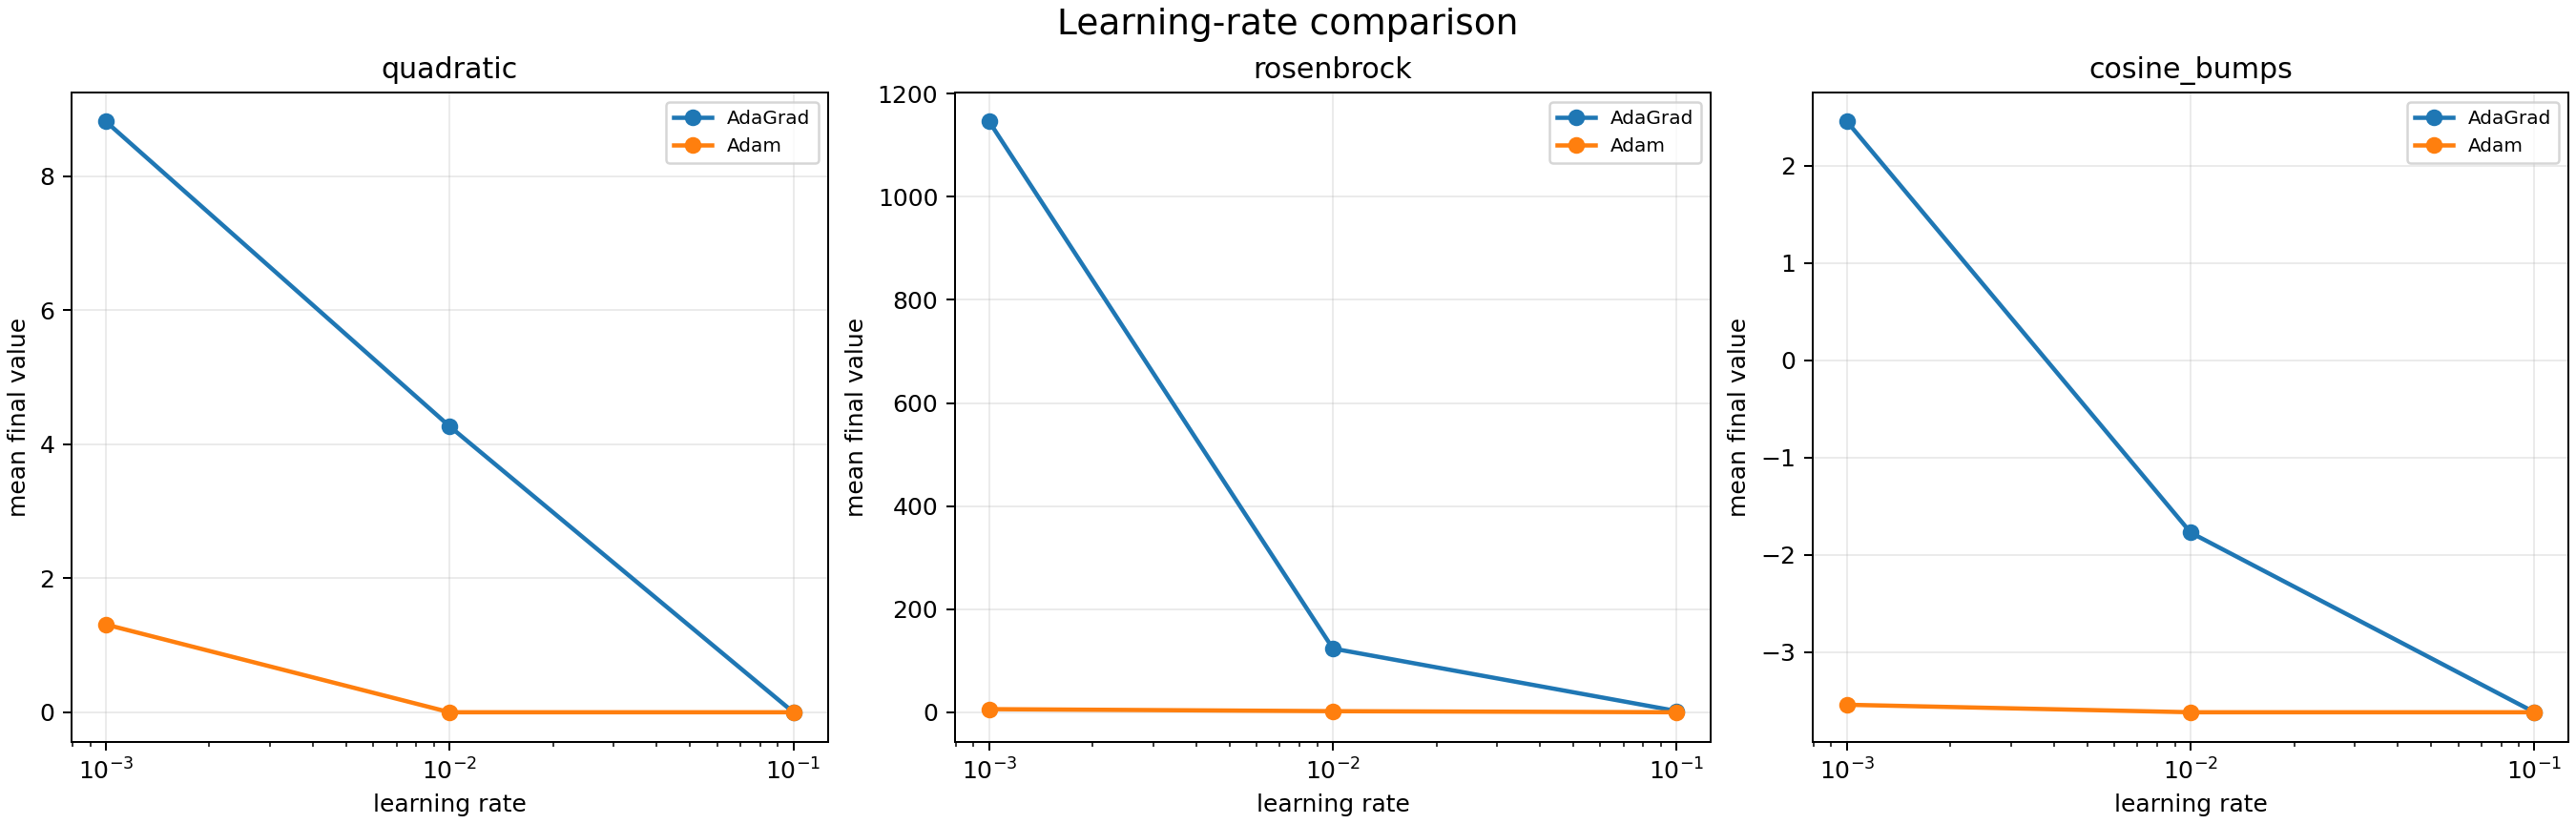

In [19]:
learning_rate_figure = FIGURE_DIR / "learning_rate_comparison.png"
print("Learning-rate comparison")
display(Image(filename=str(learning_rate_figure)))


#### 17d. Objective histories


Objective histories


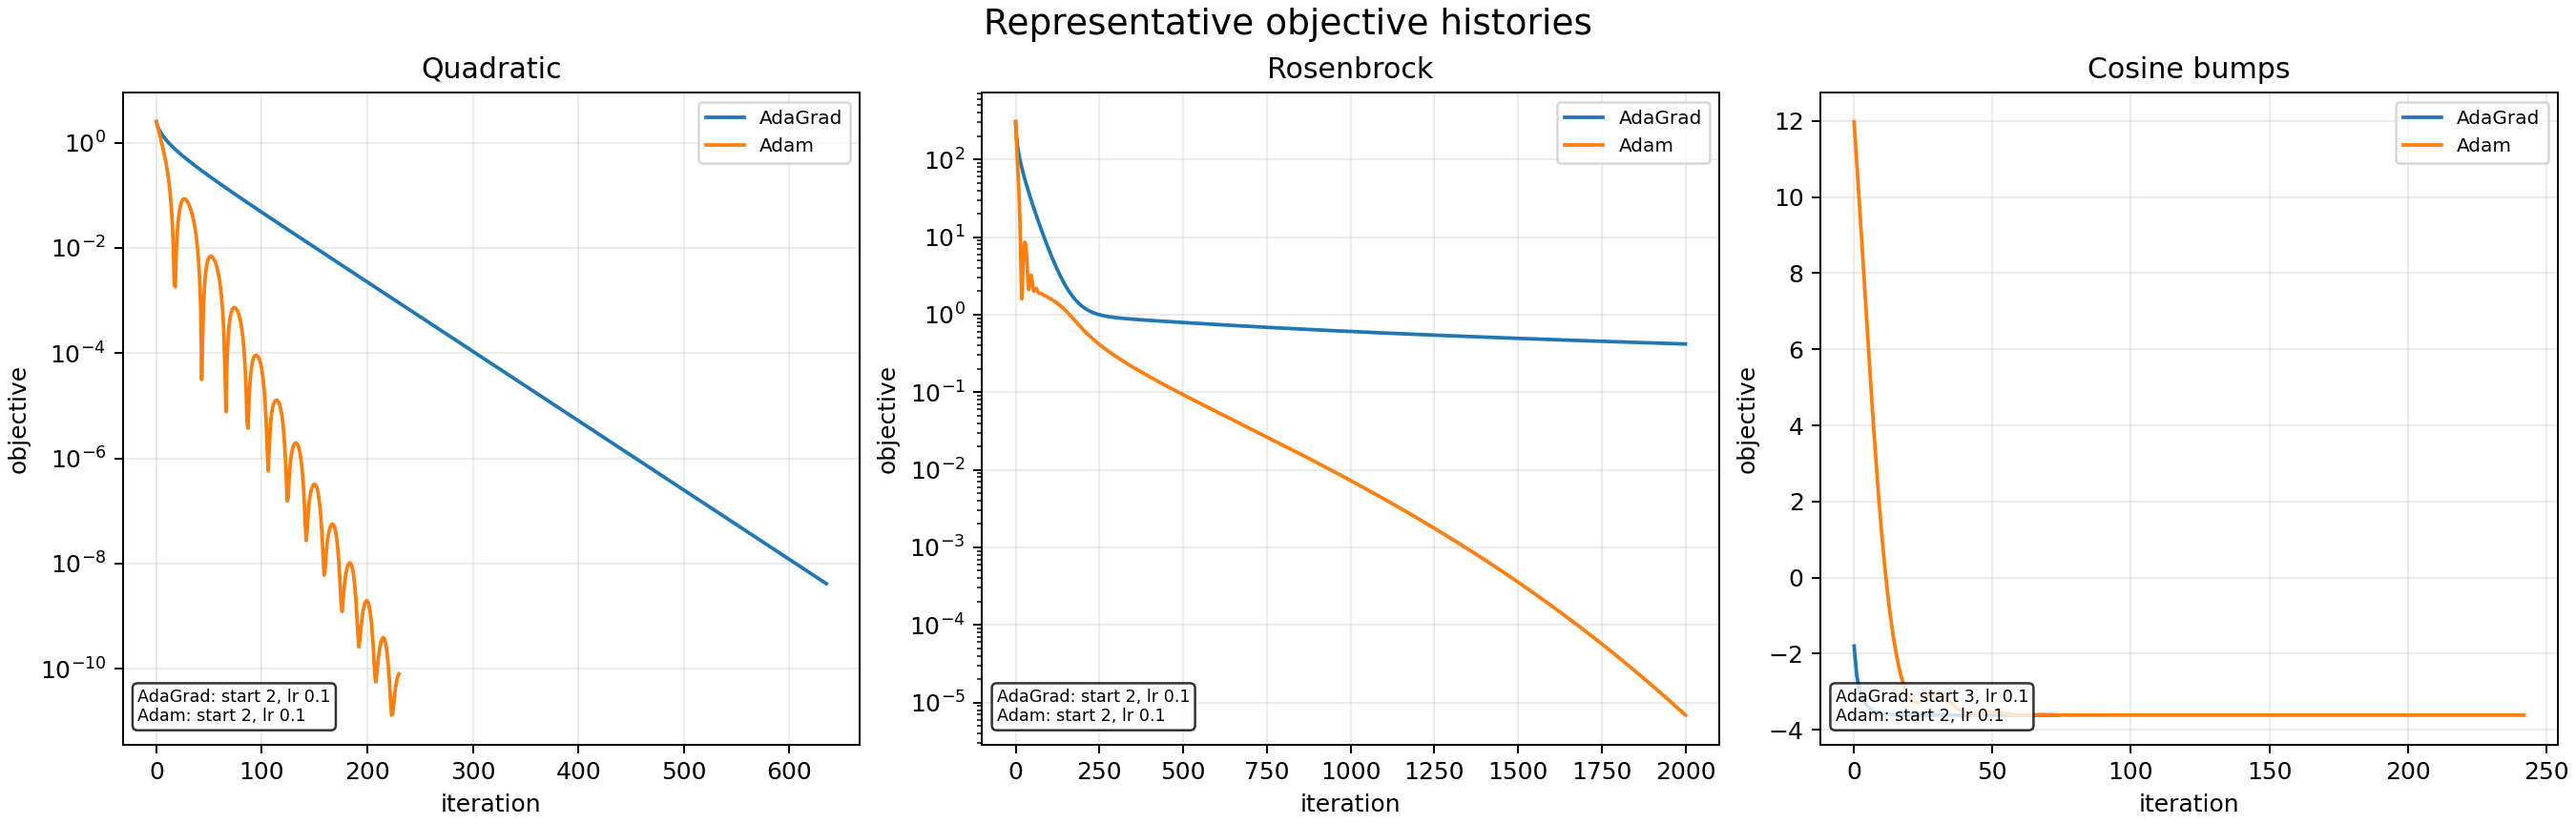

In [20]:
objective_history_figure = FIGURE_DIR / "objective_histories.png"
print("Objective histories")
display(Image(filename=str(objective_history_figure)))
